In [1]:
import os

os.makedirs("../csv", exist_ok=True)
os.makedirs("../svg", exist_ok=True)

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots

In [3]:
plt.rcParams.update({
    'font.family': 'TeX Gyre Termes',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

In [4]:
TEXTWIDTH_PT = 426.79137
TEXTHEIGHT_PT = 702.78308
PT_PER_INCH = 72.27

FIG_WIDTH = TEXTWIDTH_PT / PT_PER_INCH
FIG_HEIGHT_1 = TEXTHEIGHT_PT / PT_PER_INCH
FIG_HEIGHT_2 = FIG_HEIGHT_1 / 2
FIG_HEIGHT_3 = FIG_HEIGHT_1 / 3
FIG_HEIGHT_4 = FIG_HEIGHT_1 / 4
FIG_HEIGHT_5 = FIG_HEIGHT_1 / 5
FIG_HEIGHT_6 = FIG_HEIGHT_1 / 6
FIG_HEIGHT_7 = FIG_HEIGHT_1 / 7
FIG_HEIGHT_8 = FIG_HEIGHT_1 / 8

In [5]:
START = 8

In [6]:
def _set_edge_ticks(ax, n=4):
    ymin, ymax = ax.get_ylim()
    ax.set_yticks(np.linspace(ymin, ymax, n + 1))

In [7]:
def _set_limits(ax, df, coll, margin, factor):
    ax.set_ylim(max(np.floor((df[coll].min() - margin) / factor) * factor, 0),
                np.ceil((df[coll].max() + margin) / factor) * factor)

In [8]:
def parse_turbostat(filepath):
    samples = []
    current = {}
    header = None

    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if not parts:
                continue

            if parts[0] == "CPU":
                if current:
                    samples.append(current)
                    current = {}
                header = parts
                continue

            if header is None:
                continue

            row = dict(zip(header, parts))
            cpu = "system" if row["CPU"] == "-" else f"cpu{row['CPU']}"

            if cpu != "system":
                current[cpu] = int(row["Bzy_MHz"])
            else:
                if "PkgWatt" in row:
                    current["system_pkg_watt"] = float(row["PkgWatt"])

        if current:
            samples.append(current)

    df = pd.DataFrame(samples)
    cpu_cols_local = sorted(
        [c for c in df.columns if c.startswith("cpu")],
        key=lambda x: int(x.replace("cpu", ""))
    )
    df["system"] = df[cpu_cols_local].mean(axis=1)
    return df

In [9]:
def parse_pm(filepath):
    samples = []
    current = {}

    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith("*** Sampled system activity"):
                if current and any(k.startswith("cpu") for k in current):
                    samples.append(current)
                current = {}
                continue
            if line.startswith("CPU ") and "frequency:" in line:
                parts = line.split()
                current[f"cpu{int(parts[1])}"] = int(parts[3])
                continue
            if line.startswith("CPU Power:"):
                current["system_pkg_watt"] = float(line.split()[2]) / 1000.0

    if current and any(k.startswith("cpu") for k in current):
        samples.append(current)

    df = pd.DataFrame(samples)
    cpu_cols_local = sorted(
        [c for c in df.columns if c.startswith("cpu")],
        key=lambda x: int(x.replace("cpu", ""))
    )
    df["system"] = df[cpu_cols_local].mean(axis=1)
    return df


In [10]:
def prec(df, cols, n, q):
    t = stats.t.ppf(q, df=n - 1)

    cv_df = df[cols].copy()
    cv_df = cv_df.replace(0, np.nan)

    x = cv_df.stack().mean()
    s = cv_df.stack().std()

    cv = (s / x) * 100
    d = t * cv / np.sqrt(n)

    return d

In [11]:
GROUP_COLORS = ["#4C9BE8", "#7FB77E", "#E8A04C", "#B07FE8"]
MEDIAN_COLORS = ["#1F4E79", "#2E5E2C", "#8A5A1A", "#5A3A8A"]


def _build_long(dfs, labels, cpu_groups):
    freq_rows, watt_rows = [], []
    for df, label in zip(dfs, labels):
        df = df.iloc[START:].reset_index(drop=True)
        for group, cols in cpu_groups.items():
            freq = df[cols].replace(0, np.nan).to_numpy().ravel()
            freq_rows.append(pd.DataFrame(
                {"dataset": label, "core": group, "freq": freq[~np.isnan(freq)]}))
        watt_rows.append(pd.DataFrame(
            {"dataset": label, "watt": df["system_pkg_watt"].to_numpy()}))
    return (pd.concat(freq_rows, ignore_index=True),
            pd.concat(watt_rows, ignore_index=True))


def _recolor_medians(ax, group_order, median_palette, ref):
    medians = [ln for ln in ax.lines if mpl.colors.same_color(ln.get_color(), ref)]
    medians.sort(key=lambda ln: np.mean(ln.get_xdata()))
    for i, ln in enumerate(medians):
        ln.set_color(median_palette[group_order[i % len(group_order)]])
        ln.set_linewidth(0.8)


def plot_turbostat(dfs, labels, cpu_groups, width, filename, margin):
    if not isinstance(cpu_groups, dict):
        cpu_groups = {"": cpu_groups}
    group_order = list(cpu_groups.keys())
    single = len(cpu_groups) == 1

    df_freq, df_watt = _build_long(dfs, labels, cpu_groups)
    palette = dict(zip(group_order, GROUP_COLORS))
    median_palette = dict(zip(group_order, MEDIAN_COLORS))
    common = dict(linewidth=0.6, fliersize=0.8)

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(width, FIG_HEIGHT_3), layout='constrained', sharex=True,
            gridspec_kw={"height_ratios": [2, 1]})

        if single:
            sns.boxplot(data=df_freq, x="dataset", y="freq", order=labels,
                        color=GROUP_COLORS[0], width=0.6,
                        medianprops=dict(color=MEDIAN_COLORS[0], linewidth=1.4),
                        ax=ax1, **common)
        else:
            sns.boxplot(data=df_freq, x="dataset", y="freq",
                        hue="core", order=labels, hue_order=group_order,
                        palette=palette, width=0.8,
                        medianprops=dict(color=MEDIAN_COLORS[0], linewidth=1.4),
                        ax=ax1, **common)
            _recolor_medians(ax1, group_order, median_palette, MEDIAN_COLORS[0])
            ax1.legend(loc="best", frameon=False, title=None)
        _set_limits(ax1, df_freq, "freq", margin, 100)
        _set_edge_ticks(ax1, 4)
        ax1.set_ylabel("Częstotliwość [MHz]")
        ax1.set_xlabel("")

        sns.boxplot(data=df_watt, x="dataset", y="watt", order=labels,
                    color="#C0392B", width=0.6,
                    medianprops=dict(color="#7B241C", linewidth=1.4), ax=ax2, **common)
        _set_limits(ax2, df_watt, "watt", 5, 5)
        _set_edge_ticks(ax2, 2)
        ax2.set_ylabel("Pobór mocy [W]")
        ax2.set_xlabel("")

        if len(dfs) > 1:
            plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

        plt.savefig(f'../svg/{filename}.svg', facecolor='white')
        plt.show()

In [12]:
def plot_turbostat_line(df, cpu_groups, width, filename, margin):
    if not isinstance(cpu_groups, dict):
        cpu_groups = {"": cpu_groups}
    single = len(cpu_groups) == 1

    df = df.iloc[START:].reset_index(drop=True)
    x = df.index.to_numpy()

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax1 = plt.subplots(figsize=(width, FIG_HEIGHT_6), layout='constrained')

        freq_series = []
        for i, (group, cols) in enumerate(cpu_groups.items()):
            freq = df[cols].replace(0, np.nan).mean(axis=1).to_numpy()
            ax1.plot(x, freq, linewidth=0.8,
                     color=MEDIAN_COLORS[i % len(MEDIAN_COLORS)],
                     label=None if single else group)
            freq_series.append(freq)

        df_freq = pd.DataFrame({"freq": np.concatenate(freq_series)})
        _set_limits(ax1, df_freq, "freq", margin, 100)
        _set_edge_ticks(ax1, 4)
        ax1.set_ylabel("Częstotliwość [MHz]")
        ax1.set_xlabel("Numer próbki")
        if not single:
            ax1.legend(loc="best", frameon=False, title=None)

        plt.savefig(f'../svg/{filename}.svg', facecolor='white')
        plt.show()

In [13]:
def plot_compare(dfs, labels, cpu_groups, filename, margin):
    if not isinstance(cpu_groups, dict):
        cpu_groups = {"": cpu_groups}
    group_order = list(cpu_groups.keys())
    single = len(cpu_groups) == 1

    df_freq, df_watt = _build_long(dfs, labels, cpu_groups)
    palette = dict(zip(group_order, GROUP_COLORS))
    median_palette = dict(zip(group_order, MEDIAN_COLORS))
    common = dict(linewidth=0.6, fliersize=0.8)

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH / 2, FIG_HEIGHT_5), layout='constrained')
        if single:
            sns.boxplot(data=df_freq, x="dataset", y="freq", order=labels,
                        color=GROUP_COLORS[0], width=0.6,
                        medianprops=dict(color=MEDIAN_COLORS[0], linewidth=1.4),
                        ax=ax, **common)
        else:
            sns.boxplot(data=df_freq, x="dataset", y="freq",
                        hue="core", order=labels, hue_order=group_order,
                        palette=palette, width=0.8,
                        medianprops=dict(color=MEDIAN_COLORS[0], linewidth=1.4),
                        ax=ax, **common)
            _recolor_medians(ax, group_order, median_palette, MEDIAN_COLORS[0])
            ax.legend(loc="best", frameon=False, title=None)
        _set_limits(ax, df_freq, "freq", margin, 100)
        _set_edge_ticks(ax, 4)
        ax.set_xlabel("Backend")
        ax.set_ylabel("Częstotliwość [MHz]")
        plt.savefig(f'../svg/{filename}_freq_compare.svg', facecolor='white')
        plt.show()

        fig, ax = plt.subplots(figsize=(FIG_WIDTH / 2, FIG_HEIGHT_5), layout='constrained')
        sns.boxplot(data=df_watt, x="dataset", y="watt", order=labels,
                    color="#C0392B", width=0.6,
                    medianprops=dict(color="#7B241C", linewidth=1.4),
                    ax=ax, **common)
        _set_limits(ax, df_watt, "watt", 5, 5)
        _set_edge_ticks(ax, 4)
        ax.set_xlabel("Backend")
        ax.set_ylabel("Pobór mocy [W]")
        plt.savefig(f'../svg/{filename}_power_compare.svg', facecolor='white')
        plt.show()

In [14]:
def _report_backends(means, maxes, *, label, unit, prec):
    grand = means.mean()
    vmin, vmax = means.min(), means.max()
    dev_pct = max(abs(vmin - grand), abs(vmax - grand)) / grand * 100
    peak = maxes.max()
    peak_backend = maxes.idxmax()

    print(f"{label} per backend:")
    for backend, val in means.items():
        diff_pct = (val - grand) / grand * 100
        print(f"  {backend:<8} {val:.{prec}f} {unit}  "
              f"({diff_pct:+.2f}% od średniej, maks. {maxes[backend]:.{prec}f} {unit})")
    print(f"Zakres średnich: {vmin:.{prec}f}–{vmax:.{prec}f} {unit} (rozrzut {vmax - vmin:.{prec}f} {unit})")
    print(f"Średnia ze średnich: {grand:.{prec}f} {unit}, maks. odchył od średniej: {dev_pct:.2f}%")
    print(f"Maksimum zarejestrowane: {peak:.{prec}f} {unit} ({peak_backend})")
    print()


def compare_backends(dfs, labels, cpu_groups, *, freq_prec=0, watt_prec=2):
    if not isinstance(cpu_groups, dict):
        cpu_groups = {"": cpu_groups}
    group_order = list(cpu_groups.keys())
    single = len(cpu_groups) == 1

    df_freq, df_watt = _build_long(dfs, labels, cpu_groups)

    if single:
        grp = df_freq.groupby("dataset")["freq"]
        means = grp.mean().reindex(labels)
        maxes = grp.max().reindex(labels)
        _report_backends(means, maxes, label="Częstotliwość", unit="MHz", prec=freq_prec)
    else:
        for group in group_order:
            grp = df_freq[df_freq["core"] == group].groupby("dataset")["freq"]
            means = grp.mean().reindex(labels)
            maxes = grp.max().reindex(labels)
            _report_backends(means, maxes, label=f"Częstotliwość [{group}]",
                             unit="MHz", prec=freq_prec)

    grp = df_watt.groupby("dataset")["watt"]
    means = grp.mean().reindex(labels)
    maxes = grp.max().reindex(labels)
    _report_backends(means, maxes, label="Pobór mocy", unit="W", prec=watt_prec)

In [15]:
bench_turbostat = parse_turbostat("../data/turbostat-bench.txt")
system_turbostat = parse_turbostat("../data/turbostat-system.txt")
scalar_turbostat = parse_turbostat("../data/turbostat-search-Scalar.txt")
sse2_turbostat = parse_turbostat("../data/turbostat-search-Sse2.txt")
avx2_turbostat = parse_turbostat("../data/turbostat-search-Avx2.txt")
avx512_turbostat = parse_turbostat("../data/turbostat-search-Avx512.txt")
bench_pm = parse_pm("../data/pm-bench.txt")
system_pm_Speck32_64 = parse_pm("../data/pm-system-Speck32_64.txt")
system_pm_Speck48_72 = parse_pm("../data/pm-system-Speck48_72.txt")
system_pm_Speck48_96 = parse_pm("../data/pm-system-Speck48_96.txt")
system_pm_Speck64_96 = parse_pm("../data/pm-system-Speck64_96.txt")
system_pm_Speck64_128 = parse_pm("../data/pm-system-Speck64_128.txt")
system_pm_Speck96_96 = parse_pm("../data/pm-system-Speck96_96.txt")
system_pm_Speck96_144 = parse_pm("../data/pm-system-Speck96_144.txt")
system_pm_Speck128_128 = parse_pm("../data/pm-system-Speck128_128.txt")
system_pm_Speck128_192 = parse_pm("../data/pm-system-Speck128_192.txt")
system_pm_Speck128_256 = parse_pm("../data/pm-system-Speck128_256.txt")
scalar_pm = parse_pm("../data/pm-search-Scalar.txt")
neon_pm = parse_pm("../data/pm-search-Neon.txt")

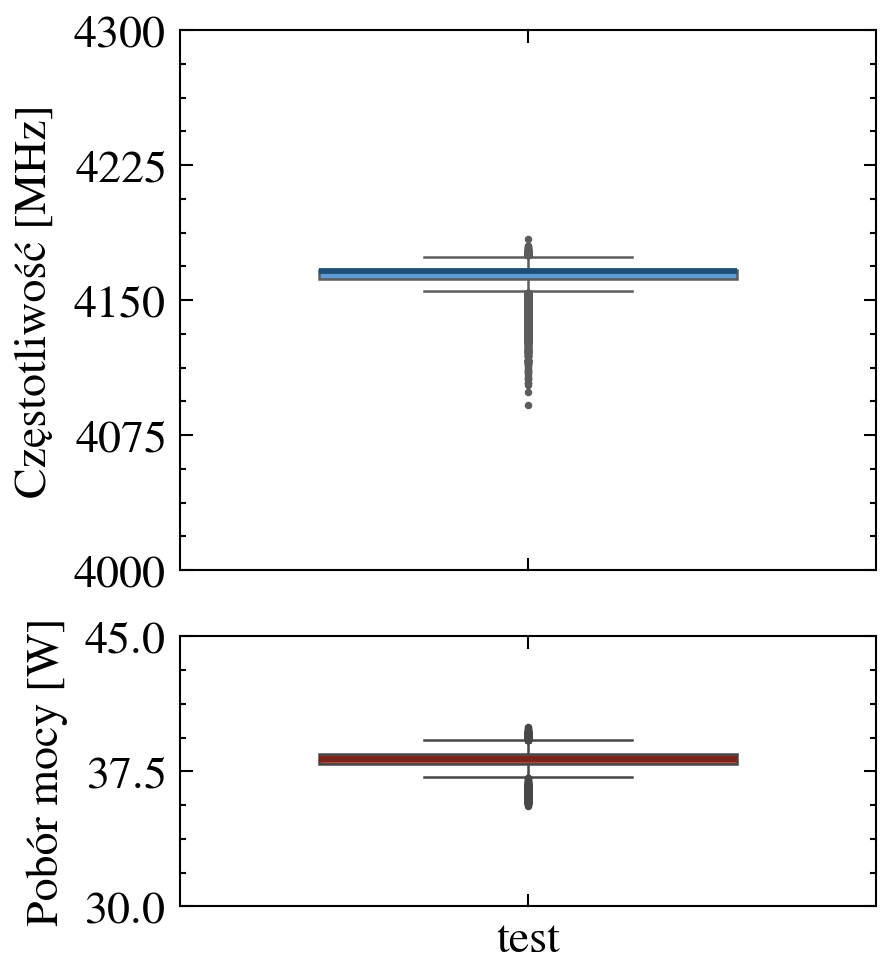

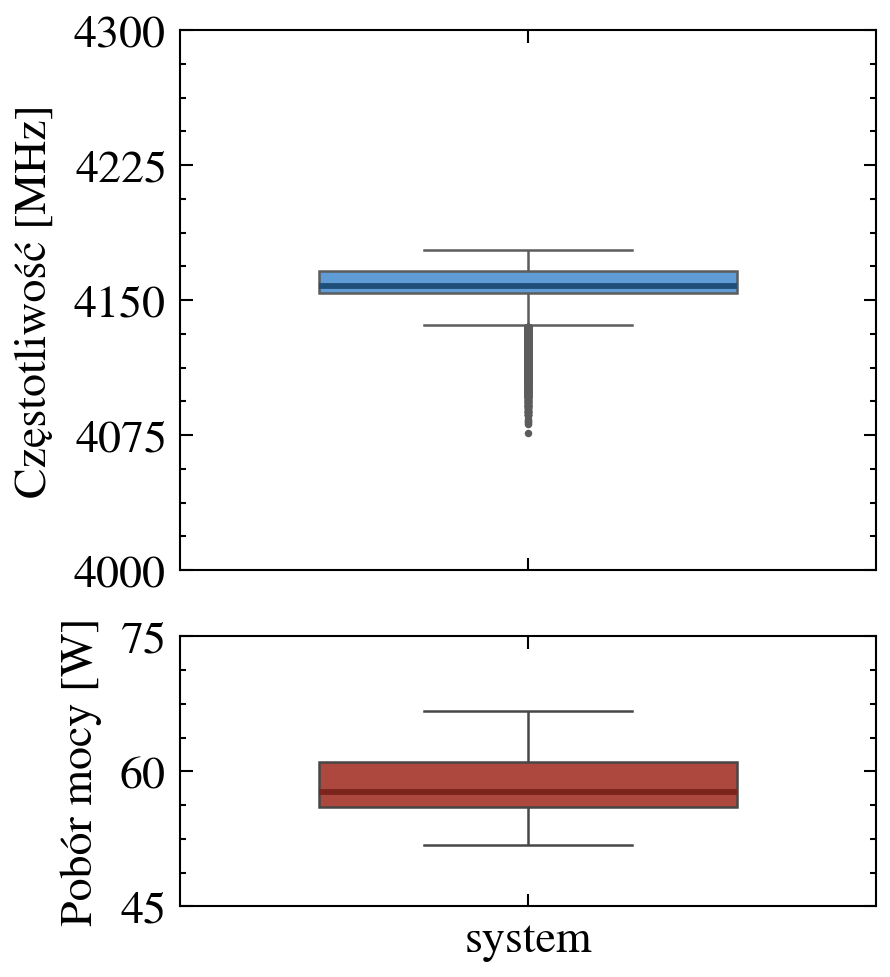

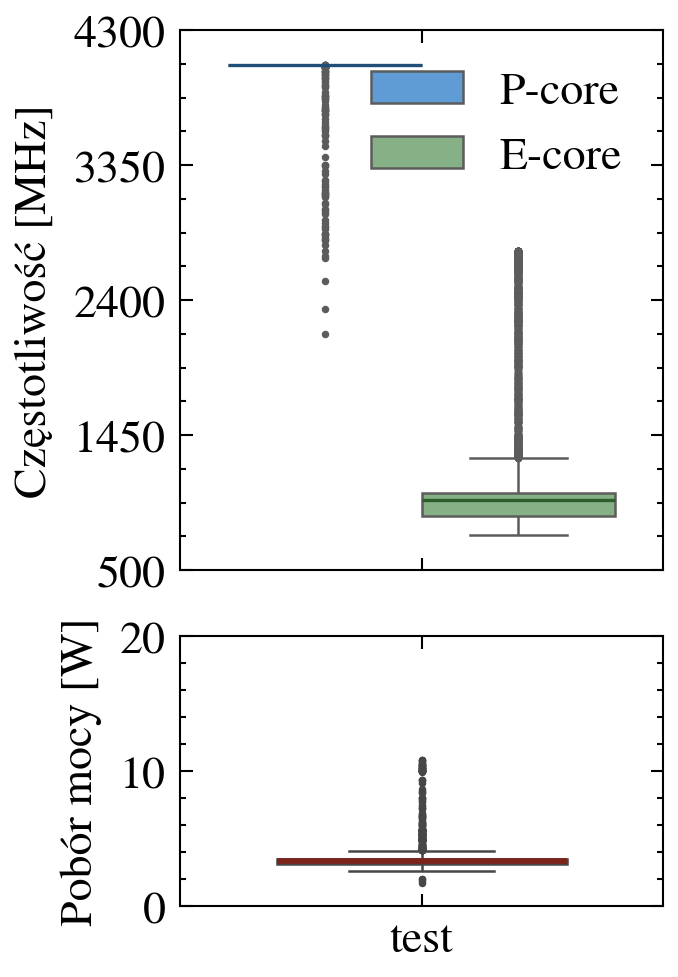

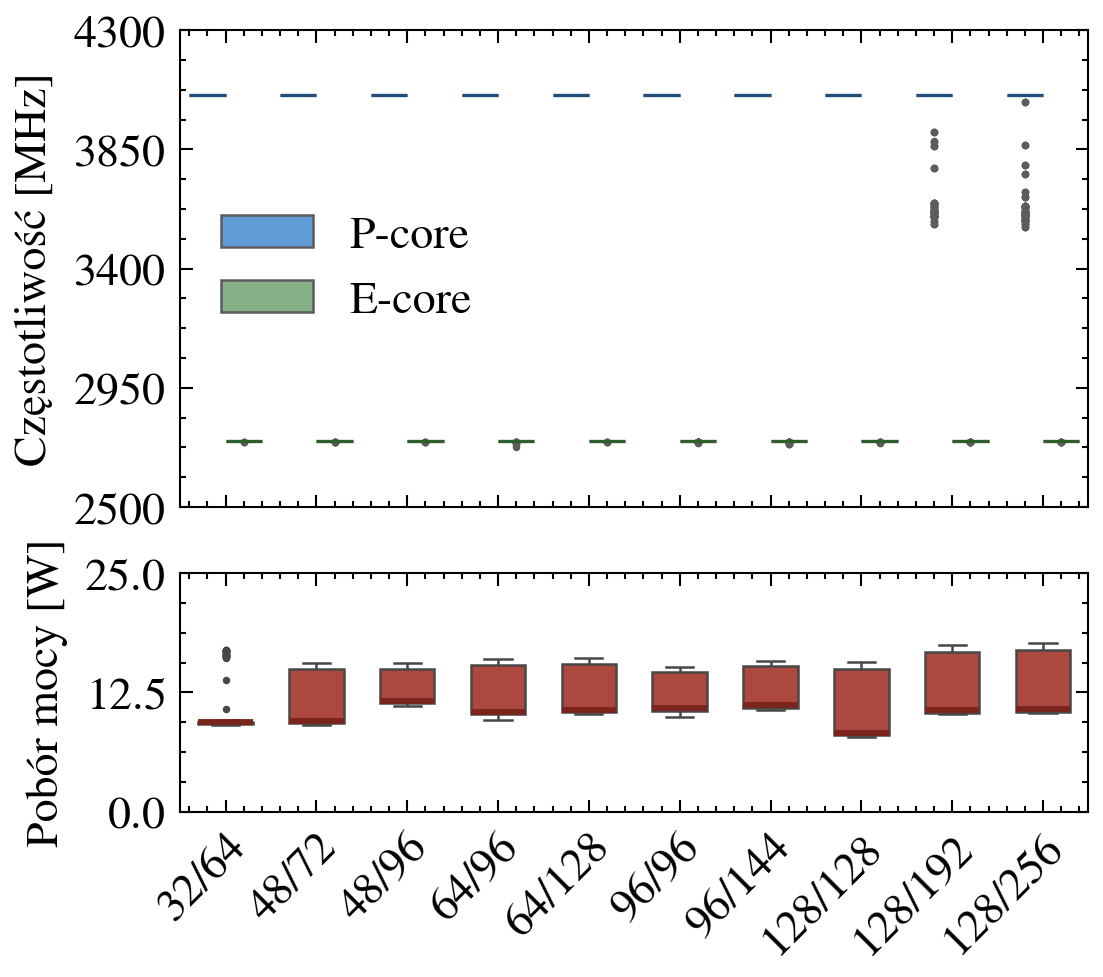

In [16]:
plot_turbostat([bench_turbostat], ['test'], [f'cpu{i}' for i in [1, 9]], FIG_WIDTH / 2, "turbostat_bench", 25)
plot_turbostat([system_turbostat], ['system'], [f'cpu{i}' for i in range(0, 16)], FIG_WIDTH / 2, "turbostat_system", 25)
plot_turbostat([bench_pm], ['test'], {
    "P-core": [f'cpu{i}' for i in range(4, 8)],
    "E-core": [f'cpu{i}' for i in range(0, 4)],
}, FIG_WIDTH * (38 / 100), "pm_bench", 200)
plot_turbostat(
    [system_pm_Speck32_64, system_pm_Speck48_72, system_pm_Speck48_96,
     system_pm_Speck64_96, system_pm_Speck64_128, system_pm_Speck96_96,
     system_pm_Speck96_144, system_pm_Speck128_128, system_pm_Speck128_192,
     system_pm_Speck128_256],
    ['32/64', '48/72', '48/96', '64/96', '64/128',
     '96/96', '96/144', '128/128', '128/192', '128/256'],
    {
        "P-core": [f'cpu{i}' for i in range(4, 8)],
        "E-core": [f'cpu{i}' for i in range(0, 4)],
    }, FIG_WIDTH * (62 / 100), "pm_system", 200)

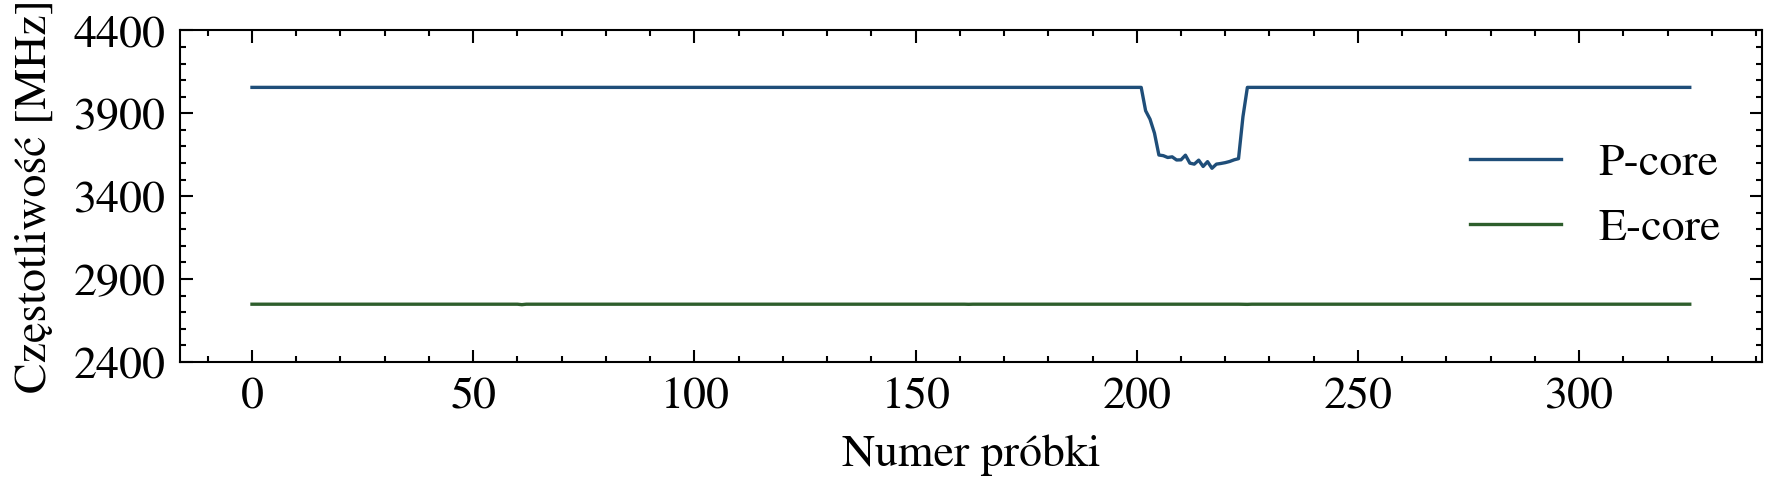

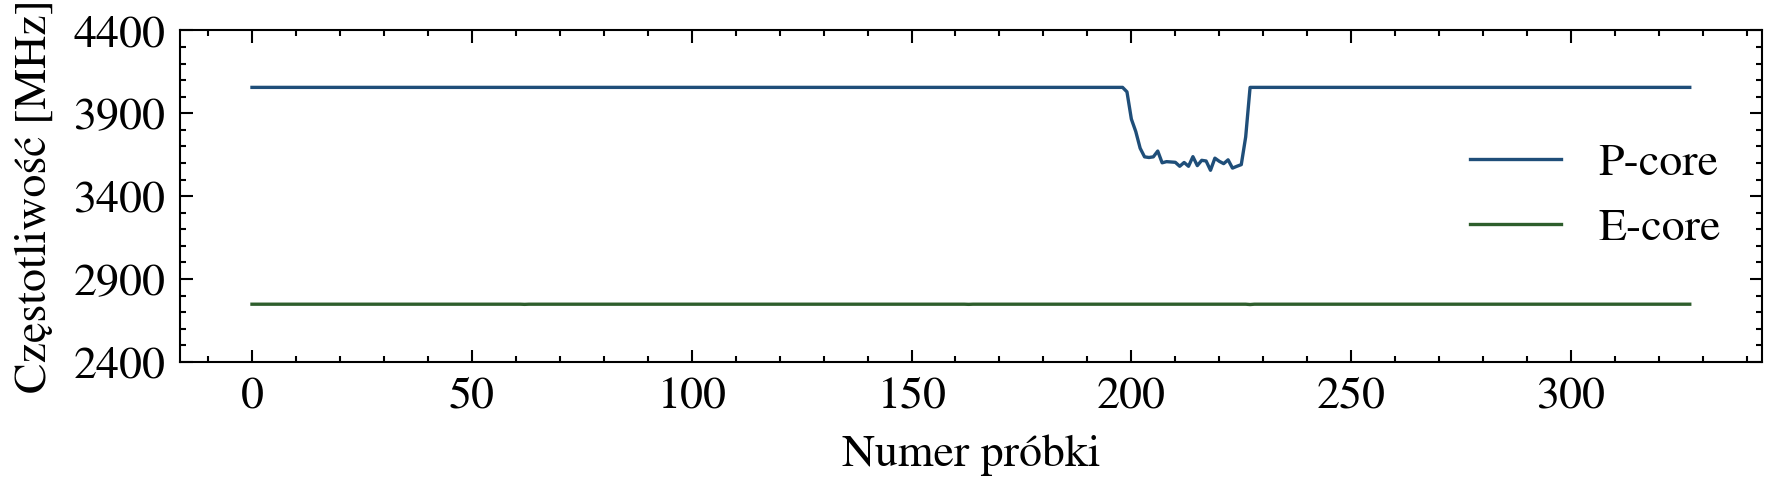

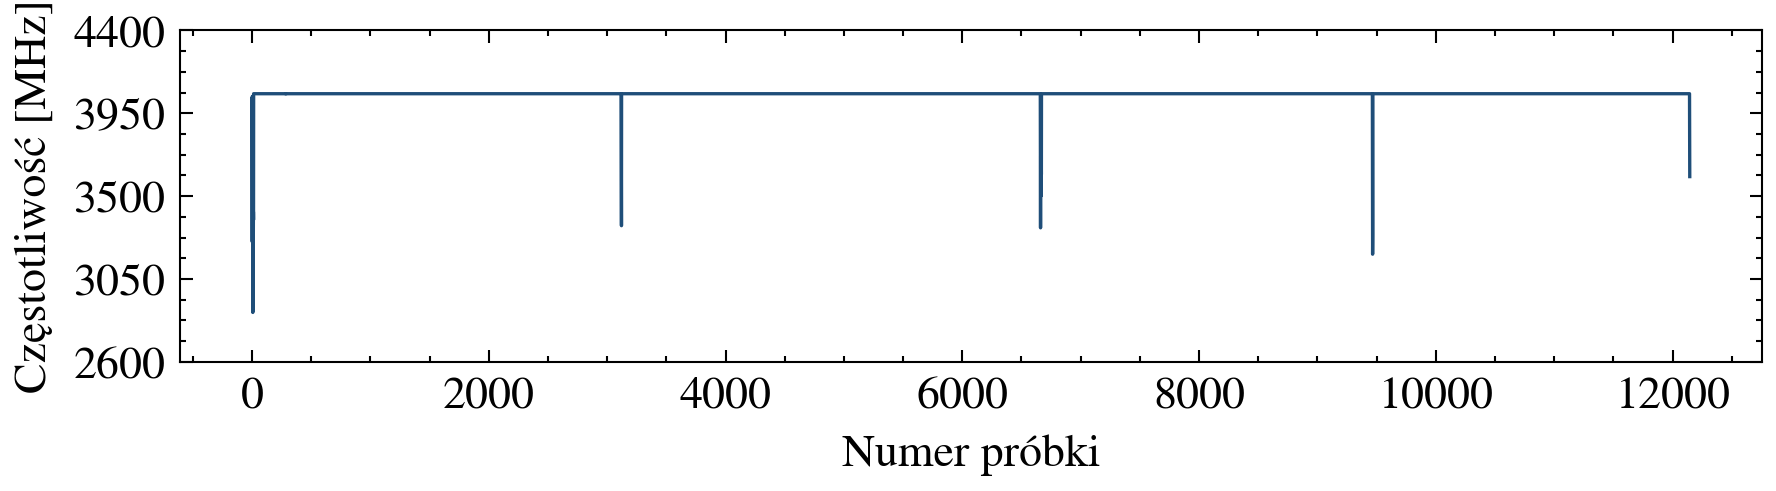

In [17]:
plot_turbostat_line(
    system_pm_Speck128_192,
    {
        "P-core": [f'cpu{i}' for i in range(4, 8)],
        "E-core": [f'cpu{i}' for i in range(0, 4)],
    }, FIG_WIDTH, "pm_system_line_Speck128_192", 250
)

plot_turbostat_line(
    system_pm_Speck128_256,
    {
        "P-core": [f'cpu{i}' for i in range(4, 8)],
        "E-core": [f'cpu{i}' for i in range(0, 4)],
    }, FIG_WIDTH, "pm_system_line_Speck128_256", 250
)

plot_turbostat_line(
    bench_pm,
    [f'cpu{i}' for i in range(4, 8)], FIG_WIDTH, "pm_bench_line", 250
)

In [18]:
turbostat_backends = {
    "Scalar": scalar_turbostat,
    "SSE2": sse2_turbostat,
    "AVX2": avx2_turbostat,
    "AVX512": avx512_turbostat,
}
turbostat_backend_order = ["Scalar", "SSE2", "AVX2", "AVX512"]

pm_backends = {
    "Scalar": scalar_pm,
    "NEON": neon_pm,
}
pm_backend_order = ["Scalar", "NEON"]

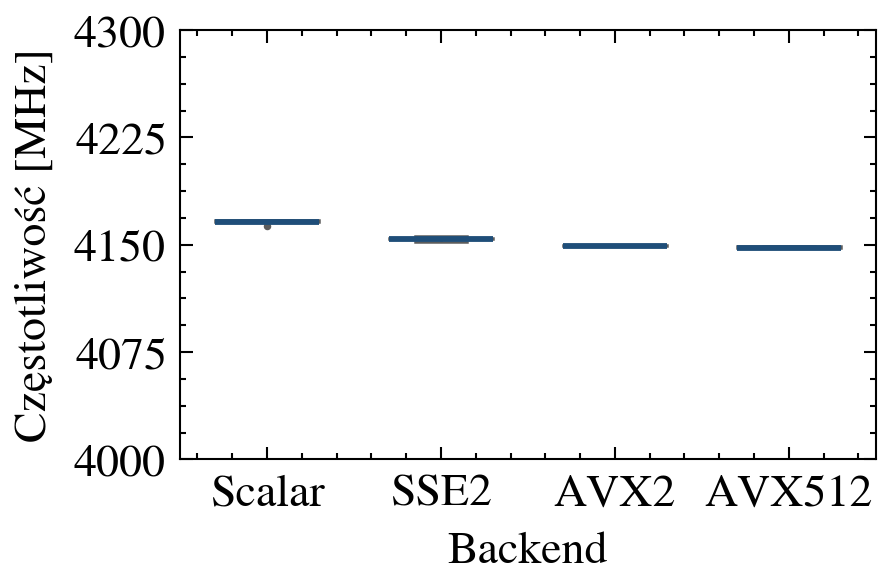

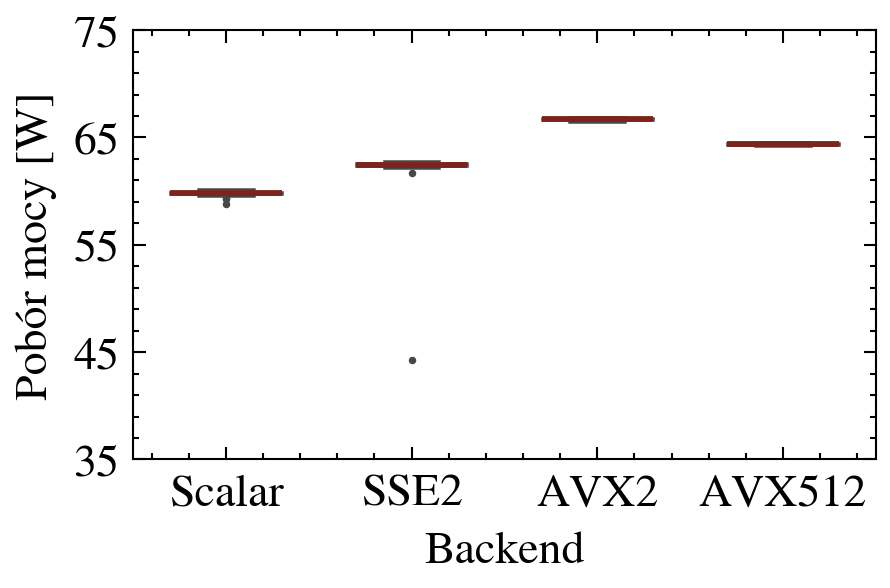

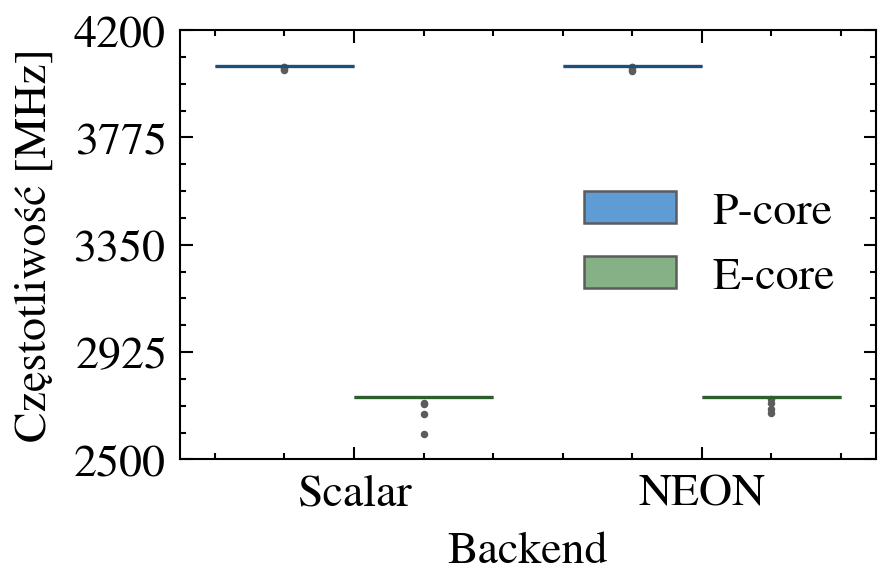

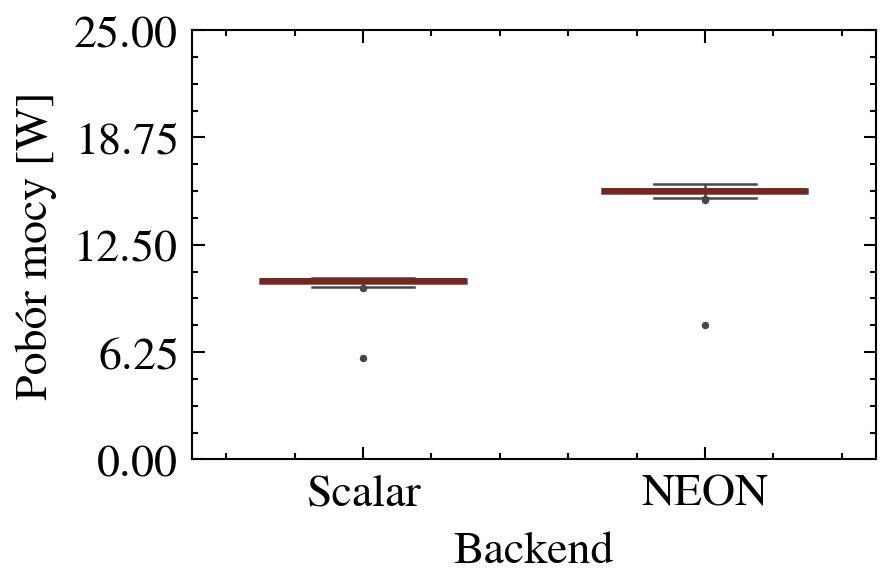

In [19]:
plot_compare(
    list(turbostat_backends.values()), turbostat_backend_order,
    [f'cpu{i}' for i in range(0, 16)],
    'turbostat',
    100
)

plot_compare(
    list(pm_backends.values()), pm_backend_order,
    {
        "P-core": [f'cpu{i}' for i in range(4, 8)],
        "E-core": [f'cpu{i}' for i in range(0, 4)],
    },
    'pm',
    100
)

In [20]:
compare_backends(
    list(turbostat_backends.values()), turbostat_backend_order,
    [f'cpu{i}' for i in range(0, 16)],
)

compare_backends(
    list(pm_backends.values()), pm_backend_order,
    {
        "P-core": [f'cpu{i}' for i in range(4, 8)],
        "E-core": [f'cpu{i}' for i in range(0, 4)],
    },
)

Częstotliwość per backend:
  Scalar   4166 MHz  (+0.29% od średniej, maks. 4167 MHz)
  SSE2     4154 MHz  (-0.01% od średniej, maks. 4156 MHz)
  AVX2     4149 MHz  (-0.13% od średniej, maks. 4150 MHz)
  AVX512   4148 MHz  (-0.15% od średniej, maks. 4149 MHz)
Zakres średnich: 4148–4166 MHz (rozrzut 18 MHz)
Średnia ze średnich: 4155 MHz, maks. odchył od średniej: 0.29%
Maksimum zarejestrowane: 4167 MHz (Scalar)

Pobór mocy per backend:
  Scalar   59.80 W  (-5.35% od średniej, maks. 60.17 W)
  SSE2     61.79 W  (-2.20% od średniej, maks. 62.76 W)
  AVX2     66.73 W  (+5.61% od średniej, maks. 66.89 W)
  AVX512   64.41 W  (+1.94% od średniej, maks. 64.56 W)
Zakres średnich: 59.80–66.73 W (rozrzut 6.93 W)
Średnia ze średnich: 63.18 W, maks. odchył od średniej: 5.61%
Maksimum zarejestrowane: 66.89 W (AVX2)

Częstotliwość [P-core] per backend:
  Scalar   4056 MHz  (+0.00% od średniej, maks. 4056 MHz)
  NEON     4056 MHz  (-0.00% od średniej, maks. 4056 MHz)
Zakres średnich: 4056–4056 MHz (roz

In [21]:
TREND_PCT_THRESHOLD = 0.5

PM_GROUPS = {
    "P-core": [f"cpu{i}" for i in range(4, 8)],
    "E-core": [f"cpu{i}" for i in range(0, 4)],
}

datasets = [
    ("Mikrobenchmarki", (bench_turbostat, ["cpu1", "cpu9"], None, "x86_64")),
    ("System", (system_turbostat, None, None, "x86_64")),
    ("Przebieg Skalarny", (scalar_turbostat, None, None, "x86_64")),
    ("Przebieg SSE2", (sse2_turbostat, None, None, "x86_64")),
    ("Przebieg AVX2", (avx2_turbostat, None, None, "x86_64")),
    ("Przebieg AVX-512", (avx512_turbostat, None, None, "x86_64")),
    ("Mikrobenchmarki", (bench_pm, [f"cpu{i}" for i in range(4, 8)], PM_GROUPS, "aarch64")),
    ("Sys. wer. 32/64", (system_pm_Speck32_64, None, PM_GROUPS, "aarch64")),
    ("Sys. wer. 48/72", (system_pm_Speck48_72, None, PM_GROUPS, "aarch64")),
    ("Sys. wer. 48/96", (system_pm_Speck48_96, None, PM_GROUPS, "aarch64")),
    ("Sys. wer. 64/96", (system_pm_Speck64_96, None, PM_GROUPS, "aarch64")),
    ("Sys. wer. 64/128", (system_pm_Speck64_128, None, PM_GROUPS, "aarch64")),
    ("Sys. wer. 96/96", (system_pm_Speck96_96, None, PM_GROUPS, "aarch64")),
    ("Sys. wer. 96/144", (system_pm_Speck96_144, None, PM_GROUPS, "aarch64")),
    ("Sys. wer. 128/128", (system_pm_Speck128_128, None, PM_GROUPS, "aarch64")),
    ("Sys. wer. 128/192", (system_pm_Speck128_192, None, PM_GROUPS, "aarch64")),
    ("Sys. wer. 128/256", (system_pm_Speck128_256, None, PM_GROUPS, "aarch64")),
    ("Przebieg Skalarny", (scalar_pm, None, PM_GROUPS, "aarch64")),
    ("Przebieg NEON", (neon_pm, None, PM_GROUPS, "aarch64")),
]

In [22]:
def _get_freq(df, cols):
    if cols is None:
        return df.iloc[START:]["system"].replace(0, np.nan).dropna()
    return df.iloc[START:][cols].replace(0, np.nan).mean(axis=1).dropna()

In [23]:
def fmt_p(p):
    if np.isnan(p):
        return "n/d"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

In [24]:
trend_rows = []
for name, (df, cols, groups, arch) in datasets:
    freq = _get_freq(df, cols)
    n = len(freq)
    if n < 3:
        continue
    x = np.arange(n, dtype=float)
    tau, p_value = stats.kendalltau(x, freq.values)
    slope_sen = stats.theilslopes(freq.values, x).slope
    slope_pct = slope_sen / freq.mean() * 100
    total_pct = slope_sen * (n - 1) / freq.mean() * 100
    statistically_significant = not np.isnan(p_value) and p_value < 0.05
    practically_significant = abs(total_pct) >= TREND_PCT_THRESHOLD
    if statistically_significant and practically_significant:
        trend = "rosnący" if tau > 0 else "malej."
    else:
        trend = "stab."

    row = {
        "name": name,
        "n": n,
        "total": f"{round(total_pct, 2):.2f}",
        "tau": f"{round(tau, 2):.2f}" if not np.isnan(tau) else None,
        "p": fmt_p(p_value),
        "trend": trend,
        "arch": arch,
    }

    if groups:
        series = []
        for i, (label, group_cols) in enumerate(groups.items()):
            suffix = "" if i == 0 else f" {label}"
            gcols = [c for c in group_cols if c in df.columns]
            series.append((suffix, _get_freq(df, gcols) if gcols else None))
    else:
        series = [("", freq)]

    for suffix, s in series:
        row[f"median{suffix}"] = str(int(s.median())) if s is not None else None

    trend_rows.append(row)

col_order = ["name", "n", "slope_sen", "total", "tau", "p", "trend", "median", "median E-core", "arch"]
df_trend = pd.DataFrame(trend_rows)
df_trend = df_trend.reindex(columns=[c for c in col_order if c in df_trend.columns])
df_trend = df_trend.fillna("n/d")
df_trend

,name,n,total,tau,p,trend,median,median E-core,arch
0,Mikrobenchmarki,13830,0.04,0.10,<0.001,stab.,4165,n/d,x86_64
1,System,5663,0.00,-0.01,0.238,stab.,4158,n/d,x86_64
2,Przebieg Skalarny,76,0.00,0.32,<0.001,stab.,4166,n/d,x86_64
3,Przebieg SSE2,28,-0.06,-0.45,0.002,stab.,4154,n/d,x86_64
4,Przebieg AVX2,11,0.00,0.10,0.705,stab.,4149,n/d,x86_64
5,Przebieg AVX-512,6,0.00,0.00,1.000,stab.,4148,n/d,x86_64
6,Mikrobenchmarki,12146,0.00,0.03,<0.001,stab.,4056,953,aarch64
7,Sys. wer. 32/64,192,0.00,0.05,0.431,stab.,4056,2748,aarch64
8,Sys. wer. 48/72,268,0.00,0.00,0.967,stab.,4056,2748,aarch64
9,Sys. wer. 48/96,272,0.00,0.00,0.982,stab.,4056,2748,aarch64


In [25]:
df_trend.to_csv(f'../csv/system_trend.csv', index=False)